# 3. Speciation, and what pays in a real porewater

Redox zonation is usually presented as a list to memorise. It is not: it
falls out of the thermodynamics once you put real concentrations in.

In [1]:
import warnings

import matplotlib.pyplot as plt

import microbial_thermo as mt

warnings.filterwarnings("ignore", category=UserWarning)

## pH speciation

Measurements come as totals — total sulfide, DIC, total ammonia — while a
reaction is written with one specific form. At pH 7 sulfide is almost an even
split, so treating a measured total as though it were all HS⁻ is wrong by
about a factor of two.

In [2]:
mt.speciation_table("sulfide", 7.0)

,species,fraction,percent,pKa to next
0,H2S(aq),0.492942,49.29416,6.99
1,HS-,0.507058,50.70584,


In [3]:
for ph in (5.0, 6.0, 7.0, 8.0, 9.0):
    member, fraction = mt.dominant("sulfide", ph)
    print(f"pH {ph}: {member.backend:8s} holds {fraction:.1%}")

pH 5.0: H2S(aq)  holds 99.0%
pH 6.0: H2S(aq)  holds 90.7%
pH 7.0: HS-      holds 50.7%
pH 8.0: HS-      holds 91.1%
pH 9.0: HS-      holds 99.0%


p*K*a values are computed from the backend at the working temperature, not
looked up, so they move with temperature:

In [4]:
for temperature in (5.0, 25.0, 60.0, 95.0):
    ladder = mt.pKa_ladder("sulfide", temperature_c=temperature)
    print(f"{temperature:5.1f} °C   pKa = {ladder[0]:.2f}")

  5.0 °C   pKa = 7.31
 25.0 °C   pKa = 6.99


 60.0 °C   pKa = 6.65
 95.0 °C   pKa = 6.49


Give a family total and the split is handled for you:

In [5]:
anoxic = mt.Conditions(
    temperature_c=12.0,
    pH=7.4,
    activity_model="ideal",
    total_concentrations={"sulfide": 1e-5, "DIC": 3e-3},
    concentrations={
        "SO4-2": 2.0e-2, "NO3-": 5e-6, "Fe+2": 5e-5, "Mn+2": 2e-5,
        "acetate": 1e-5, "NH4+": 1e-4, "NO2-": 1e-7, "lactate": 1e-6,
        "methanol": 1e-6, "O2(aq)": 1e-6,
    },
    partial_pressures={"H2(g)": 5e-6, "CH4(g)": 1e-3},
)

## The curated library

Named metabolisms, so you do not have to remember which couples to pair.

In [6]:
from microbial_thermo.library import default_library, energy_table

library = default_library()
print(f"{len(library)} metabolisms in {len(library.groups())} groups")
print(library.groups())

31 metabolisms in 13 groups
['aerobic respiration', 'sulfur oxidation', 'nitrification', 'metal oxidation', 'denitrification', 'nitrogen', 'metal reduction', 'sulfate reduction', 'sulfur reduction', 'methanogenesis', 'methane oxidation', 'acetogenesis', 'syntrophy']


In [7]:
mt.metabolism("anammox")

Metabolism(name='anammox', label='Anaerobic ammonium oxidation (anammox)', group='nitrogen', donor=('NH4+', 'N2(aq)'), acceptor=('N2(aq)', 'NO2-'), key_element=None, organisms='Brocadia, Kuenenia', note='')

## What actually pays here

In [8]:
table = energy_table(anoxic)
table[["label", "group", "dG per e- (kJ/mol)", "reaction"]]

,label,group,dG per e- (kJ/mol),reaction
0,Aerobic acetate oxidation,aerobic respiration,-101.813011,1/4 Acetate + 1/4 H+ + 1/2 O2(aq) -> 1/2 CO2(a...
1,Aerobic methanotrophy,aerobic respiration,-101.654409,1/4 Methane(aq) + 1/2 O2(aq) -> 1/4 CO2(aq) + ...
2,Aerobic hydrogen oxidation (Knallgas),aerobic respiration,-100.804878,H2(g) + 1/2 O2(aq) -> H2O
3,Elemental sulfur oxidation with oxygen,sulfur oxidation,-96.003342,1/3 Sulfur(s) + 1/3 H2O + 1/2 O2(aq) -> 1/3 SO...
4,Anaerobic ammonium oxidation (anammox),nitrogen,-94.850854,2/3 NH4+ + 2/3 NO2- -> 2/3 N2(aq) + 4/3 H2O
5,Iron(II) oxidation with oxygen,metal oxidation,-94.077520,2 Fe++ + 3 H2O + 1/2 O2(aq) -> 2 Goethite + 4 H+
6,Sulfide oxidation with oxygen,sulfur oxidation,-93.566495,1/4 HS- + 1/2 O2(aq) -> 1/4 SO4-- + 1/4 H+
7,Denitrification with acetate,denitrification,-91.560045,1/4 Acetate + 13/20 H+ + 2/5 NO3- -> 1/2 CO2(a...
8,Denitrification with hydrogen,denitrification,-90.551912,2/5 H+ + H2(g) + 2/5 NO3- -> 1/5 N2(aq) + 6/5 H2O
9,Sulfide oxidation with nitrate,sulfur oxidation,-83.313528,1/4 HS- + 3/20 H+ + 2/5 NO3- -> 1/4 SO4-- + 1/...


## The affinity ladder

The same data as a figure. Bars reaching into the shaded band are exergonic
but probably too weakly so to conserve energy for a cell.

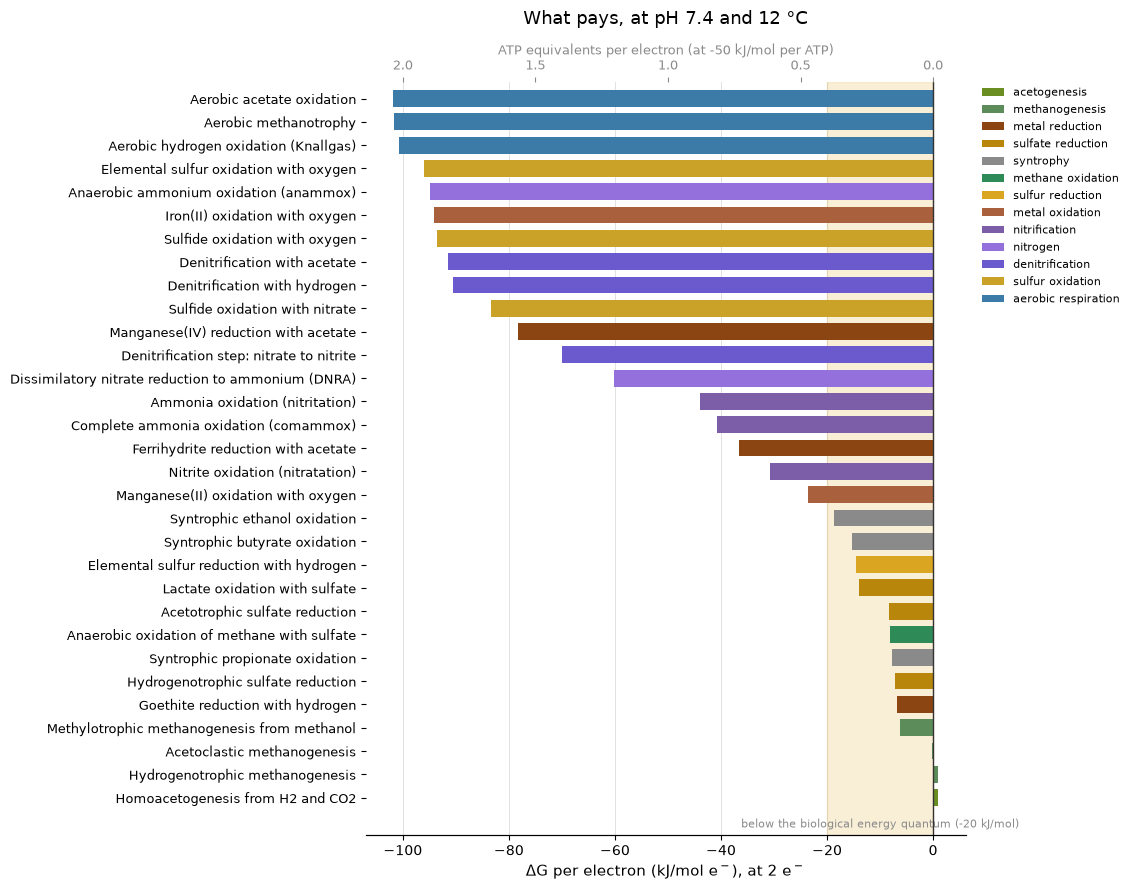

In [9]:
from microbial_thermo.figures import plot_affinity_ladder

plot_affinity_ladder(anoxic, figsize=(11.5, 9))
plt.show()

Notice what has happened. At standard state the aerobic metabolisms win by a
wide margin and sulfate reduction is comfortably exergonic. Under this
porewater — oxygen nearly gone, hydrogen at 5 nM — the sulfate and methane
metabolisms have collapsed into the energy-quantum band, which is exactly the
regime where syntrophy and very low product concentrations become necessary.

### Exercise

Raise the hydrogen partial pressure to $10^{-3}$ bar and redraw. Which
metabolisms move out of the band, and why those ones?

## Comparing the same metabolism across conditions

In [10]:
from microbial_thermo.library import reaction as build

standard = mt.Conditions(temperature_c=25.0, pH=7.0)
for name in ("acetotrophic_sulfate_reduction", "hydrogenotrophic_methanogenesis"):
    at_standard = build(name, standard).delta_G_per_electron.magnitude
    in_situ = build(name, anoxic).delta_G_per_electron.magnitude
    print(f"{name:38s} standard {at_standard:+7.1f}   in situ {in_situ:+7.1f} kJ/mol e-")

acetotrophic_sulfate_reduction         standard    -5.1   in situ    -8.2 kJ/mol e-
hydrogenotrophic_methanogenesis        standard   -15.4   in situ    +0.8 kJ/mol e-
